# Optimization Code:

In [1]:
# =============== Imports ===============
import numpy as np
#from iminuit import Minuit
#from iminuit.cost import UnbinnedNLL
from scipy.stats import norm
#import panel as pn
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
from matplotlib.backends.backend_pdf import PdfPages
# Optimization library
#!pip install nevergrad
import nevergrad as ng
# Library to track the progress of the optimization
from tqdm import tqdm
import json


# Sets the floats to round instead of going into scientific notation
np.set_printoptions(suppress=True, formatter={'float_kind':'{:0.10f}'.format})

In [2]:
# =============== Function definitions ===============

# Applies a rotation matrix to points, rotating them over that angle
def rotate_points(x, y, phi):  
    x_rot = x * np.cos(phi) - y * np.sin(phi)
    y_rot = x * np.sin(phi) + y * np.cos(phi)
    return x_rot, y_rot

# Applies a reflection matrix to points, reflecting them over that angle
def reflect_points(x, y, phi):  
    x_ref = x * np.cos(2 * phi) + y * np.sin(2 * phi)
    y_ref = x * np.sin(2 * phi) - y * np.cos(2 * phi)
    return x_ref, y_ref

# Plots conductors over an angular range, starting at some initial angle from x-axis (need to generalize to inter-block spacing)
def plotter(lower_ang, rad, point_num):

    # Angle of the conductor block
    delta_phi_block = (point_num*2*wire_rad)/(rad) # True values of the arc length

    # The lower bound, given by the spacing of the point
    lower_ang = np.deg2rad(lower_ang)

    # Angle taken up by a single conductor point
    dphi_point = 2 * np.arcsin(wire_rad / rad)

    # linspace evenly distributes points, which is not what we want
    # So we use np.arange, which distributes at a fixed interval
    # Creates a phi list where points are adjacent to eachother
    phi_list = lower_ang + (np.arange(point_num) * dphi_point) + (dphi_point/2)
    # Adding this additional dphi_point/2 term allows the angles to start at the radius of the conductor and not at the center

    # Converts points to carteisan so that we can plot them
    x = rad*np.cos(phi_list)
    y = rad*np.sin(phi_list)
    return x, y

# Plots a circle given a radius and a color
def circ_plot(rad, color='k--'):
    circ = np.linspace(0, 2*np.pi, 500)
    x = rad * np.cos(circ)
    y = rad * np.sin(circ)
    plt.plot(x, y, color, zorder=1)

# The field defined in terms of the harmonic contributions
def B_harm(x, y, x_a, y_a, I):
    # Position of the conductor
    a = np.hypot(x_a, y_a)
    
    # Position of field measurement
    r = np.hypot(x, y)
    # Replace r=0 with r=1e-20 to avoid divsion by zero
    r = np.where(r == 0, 1e-10, r)

    # Angle between a and y=0
    phi = np.arctan2(y_a, x_a)
    # Angle between r and y=0
    theta = np.arctan2(y, x)

    # Angle between r and a
    ang = phi - theta

    # Now we compute the field for both cases, adding up harmonics until the n_max harmonic is calculated and added

    # Case for r < a:
    B_r_in = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.sin(n * ang) for n in range(1, n_max+1)], axis=0)
    B_theta_in = (-1)*((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.cos(n * ang) for n in range(1, n_max+1)], axis=0)
    
    # Case for r > a:
    B_r_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.sin(n * ang) for n in range(0, n_max+1)], axis=0)
    B_theta_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.cos(n * ang) for n in range(0, n_max+1)], axis=0)

    # Case for r=a:
    B_r_eq = ((mu0 * I) / (2 * np.pi * a)) * np.sum([np.sin(n * ang) for n in range(1, n_max+1)], axis=0)  #changed
    B_theta_eq = (-1) * ((mu0 * I) / (2 * np.pi * a)) * np.sum([np.cos(n * ang) for n in range(1, n_max+1)], axis=0)  #changed

    # Use np.where to select the correct field values to return
    # np.where(cond., x, y) -> If true, takes x; if false, takes y

    r_eq_a = np.abs(r - a) < 1e-12

    # Compares if r <, >, = to a:
    B_r = np.where(r_eq_a, B_r_eq, np.where(r > a, B_r_out, B_r_in))
    B_theta = np.where(r_eq_a, B_theta_eq, np.where(r > a, B_theta_out, B_theta_in))
    
    # Convert to cartesian coordinates (notably using the angle theta, not ang)
    B_x = B_r * np.cos(theta) - B_theta * np.sin(theta)
    B_y = B_r * np.sin(theta) + B_theta * np.cos(theta)

    return B_x, B_y

# To calculate the individual harmonic at ref_rad (R0) due to a conductor with current I at position (a, phi)
# Poles go by (n+1), so n=2 -> 3phi -> Sextupole
# 0 = Dipole, 1=Quadrupole, 2=Sextupole, etc.
# For a dipole, even harmonics are not allowed, so here we just look at odd constributions (example)
def Harmonic(R0, a, phi, n, I_wire):
    return (mu0*I_wire/2*np.pi) * (10**4) * ((R0 / a)**n) * np.cos((n + 1) * phi)

# Skew-Harmonic - appears when there is asymmetry in the conductor distribution:
def skew_Harmonic(R0, a, phi, n, I_wire):
    return (mu0*I_wire/2*np.pi) * (10**4) * ((R0 / a)**n) * np.sin((n + 1) * phi)

# For formatting output values into pretty scientific notation:
def sci_fmt(x, digits=3):
    s = f"{x:.{digits}e}"
    base, exp = s.split("e")
    exp = int(exp)
    return f"{base}×10^{exp}"

def draw_line_from_xaxis(ax, x0, angle, length, degrees=False, **kwargs):
    """
    Draws a line starting at (x0, 0) on the existing magnet plot.

    Parameters:
        ax      : matplotlib axis on which to draw
        x0      : starting x-coordinate (on x-axis)
        angle   : angle above x-axis
        length  : line length
        degrees : if True, angle is interpreted in degrees
        **kwargs: passed to ax.plot (color, linestyle, etc.)
    """
    if degrees:
        angle = np.deg2rad(angle)

    x1 = x0 + length * np.cos(angle)
    y1 =      length * np.sin(angle)

    ax.plot([x0, x1], [0, y1], **kwargs)

In [3]:
# =============== User defined varaiables ===============

# Can be read through a JSON or something of that nature
settings = {
    # Physical constants
    "mu0": 4 * np.pi * 1e-7,        # Permeability of vacuum

    # Field calculation
    "n_max": 10,                   # Max n values for field calculation
    "mag_type": 1,                 # 1=dipole, 2=quadrupole, 3=sextupole, etc.

    # Geometry
    "aper_rad": 0.1,               # Aperture radius (m)
    "ref_rad": 0.025,              # Reference radius (m)
    "wire_rad": 0.002,             # Wire radius (m)
    "t": 0.005,                    # Thickness of spacing between layers (m)
    # Change to 0.0005 
    
    "dr": 0,                    # Radial spacing (computed below)

    # Current
    "I0": 500,                     # Current magnitude (A)

    # Symmetry
    "sym_angle": 0,             # Computed below

    # Flags / state
    "unphys_error": False,         # Set True if overlap error encountered
    "png_override": False,         # Produce only PNG output
    "show_sym_angles": False,      # Show symmetry lines (PNG only)
    "plot_mode": False,            # True once optimal geometry is found

    # Plot settings
    "surf_plot": True,             # Surface plot for field strength
    "all_quads": True              # Show all quadrants
}

# Assigns dictonary values to variable names to make them easier to use
mu0 = settings["mu0"]
n_max = settings["n_max"]
mag_type = settings["mag_type"]
aper_rad = settings["aper_rad"]
ref_rad = settings["ref_rad"]
wire_rad = settings["wire_rad"]
t = settings["t"]
dr = settings["dr"]
I0 = settings["I0"]
sym_angle = settings["sym_angle"]
unphys_error = settings["unphys_error"]
png_override = settings["png_override"]
show_sym_angles = settings["show_sym_angles"]
plot_mode = settings["plot_mode"]
surf_plot = settings["surf_plot"]
all_quads = settings["all_quads"]

# Since dr & sym_angle are derived, we need to assign them as keys and values after they are calculated
dr = wire_rad+0.002
settings["dr"] = dr
sym_angle = (np.pi)/(2*mag_type)
settings["sym_angle"] = sym_angle

In [4]:
# =============== Layer definition ===============

"""
# Without relative spacing
layers = [
    [ [2], [5] ],
    [ [3], [15] ],
    [ [4], [10] ]
]

# With relative spacing
layers = [
    [ [2, 2, 2], [20, 10, 10] ],
    [ [3], [15] ],
    [ [4], [10] ]
]
"""
"""
layers = [
    [ [2, 2], [20, 10] ],
    [ [3], [15] ],
    [ [4], [10] ]
]
"""
"""
layers = [
    [ [2, 2, 2], [5, 2, 2] ],
    [ [3], [5] ],
    [ [5], [5] ]
]
"""
"""
layers = [
    [ [2, 2, 1], [1, 2, 3] ],
    [ [3, 1], [2, 1] ],
    [ [7], [5] ]
]

layers = [
    [ [1, 2, 2], [5, 3, 1] ],
    [ [3, 3],    [5, 2]    ],
    [ [7],       [5]        ]
]

layers = [
    [ [2], [1] ],
    [ [3, 1], [2, 1] ],
    [ [4, 2, 1], [1, 2, 4] ]
]

layers = [
    [ [5, 3], [2, 10] ],
    [ [3, 5], [5, 10] ]
]
"""

with open("init_config.json", "r") as f:
    config = json.load(f)

layers = []

for layer in config["layers"]:
    layers.append([
        layer["conductors"],     # cond_nums
        layer["spacings_deg"]    # relative spacings (degrees)
    ])

#print(layers)


In [5]:
def geometry_generation():
    # Geometry definition:
    # =============== Geomerty calculations ===============
    
    # Arrays of the x and y values per layer in quadrant 1
    x_quad1 = []
    y_quad1 = []
    
    # A list of radii to plot based on the layer spacing:
    global rads
    rads = []
    #rads = [aper_rad + dr + i*(dr + t) for i in range(len(layers))]
    # Loops over each layer
    
    # A list of radii to plot based on the layer spacing, starting dr away from aperture radius:
    rads = [aper_rad + (2*i+1)*dr + i*t  for i in range(len(layers))]
    #   print(f"Rads: {rads}")
    
    # This gives a list of the lists of conductor numbers per layer
    cond_nums = [layer[0] for layer in layers]
    # print(f"Cond_nums: {cond_nums}")
    
    # This gives a list of lists ofall the relative spacing per layer (provided by the user):
    rel_spacing = [layer[1] for layer in layers]
    #  print(f"Relative Spacing: {rel_spacing}")
    
    # This gives a list of lists of all the spacings per layer (from the x-axis)
    #spacings = [[np.deg2rad(s) for s in layer[1]] for layer in layers]
    #print(f"Spacings From x-Axis: {spacings}")
    
    
    
    # Now we need to make a list of the delta theta values on a per layer basis
    # Once we have this, we can add the spacing angles to see if the configuration is valid
    # Need to also make sure that spacing is enough given the arc length
    
    # This gives us a list of values that tells us the angle taken up by each conductor in degrees
    # Rads and cond_nums should have the same length, that being the number of conductors
    delta_thetas = []
    for i, rad in enumerate(rads):
        temp = []
        for j, num in enumerate(cond_nums[i]):
            theta = np.rad2deg((2*num*wire_rad)/(rad)) # Angle taken up by a single conductor block
            temp.append(theta)
        delta_thetas.append(temp)
    # print(f"Delta Thetas: {delta_thetas}")
    
    # Using this info, we can make a list of lower angles to use with plotter, so we know what lower angle to start our conductor blocks at
    # This allows us to use relative spacing
    lower_angles = []
    for i, space_list in enumerate(rel_spacing): # For each layer
        # Angle offset should accumulate as we iterate over the layer
        angle_offset_sum = 0 # Resets on a per layer basis
        temp = []
        for j, space in enumerate(space_list):
            temp.append(angle_offset_sum + space)
            # Angle offset is equal to the total so far, plus the delta theta at that same point
            angle_offset_sum += delta_thetas[i][j] + space
        lower_angles.append(temp)
    
    x_quad1 = []
    y_quad1 = []
    
    # This will need to be changes to reflect that it is relative spacing
    # Plotter takes in some lower angle that we call "spacing", it does not necessarily have to be the absolute spacing
    
    
    """
    for i, layer in enumerate(layers):
        for j, space in enumerate(layer[1]):
            x, y = plotter(space, rads[i], layers[i][0][j])
            x_quad1.append(x)
            y_quad1.append(y)
    
    """
    
    # We have to start by looping over layers since we have that many layers to plot:
    for i, cond_num_list in enumerate(cond_nums): # For each layer's sublist
        for j in range(len(cond_num_list)):
          #  print(lower_angles[i][j])
           # print(rads[i])
           # print(cond_num_list[j])
            x, y = plotter(lower_angles[i][j], rads[i], cond_num_list[j])
            x_quad1.append(x)
            y_quad1.append(y)
    
    
    
    
    # print("")
    # print("Radii of Conductor Layers:", [f"{r:.5f}" for r in rads])
    #print("Layer spacings:", [rads[i+1] - rads[i] for i in range(len(rads)-1)])
    #print("")
    
    
    # Concatenation puts them all into just one list
    # Concatenated list is still in block order
    x_totq1 = np.concatenate(x_quad1)
    y_totq1 = np.concatenate(y_quad1)
    
    
    # =============== Symmetry mirroring ===============
    
    # Can use a while loop here too, num_sectors is the flag (?)
    
    # Angular spacing between reset lines (reset angle)
    reset_angle = np.pi / mag_type
    
    # Offset to mid-axis in each block (symmetry angle)
    reflect_angle = np.pi / (2 * mag_type)
    
    # Total number of angular sectors (i.e. reset angles)
    # This is the total amount of times we need to iterate
    num_sectors = 2 * mag_type
    
    x_blocks = []  
    y_blocks = []  
    
    # Loop over the total number of reset sectors
    for j in range(num_sectors): 
        # Starting angle
        block_start = j * reset_angle     
        # Defines the mid-axis to reflect over (starting angle for iteration + reflect angle)
        mid_axis = block_start + reflect_angle   
    
        # Rotate base pattern over by the block start value angle
        xr, yr = rotate_points(x_totq1, y_totq1, block_start)
        x_blocks.append(xr)                                    
        y_blocks.append(yr)                                    
    
        # Reflect across mid-axis of this block
        xr_ref, yr_ref = reflect_points(xr, yr, mid_axis)      
        x_blocks.append(xr_ref)                                
        y_blocks.append(yr_ref)                                
    
    # Final conductor positions used everywhere below:
    global x_tot
    global y_tot
    x_tot = np.concatenate(x_blocks) 
    y_tot = np.concatenate(y_blocks)
    
    # =============== Geometry checks ===============
    
    #print(f"Radii of Conductor Layers: {[round(r, 2) for r in rads]}")
    
    # Last value in the rads list:
    max_rad = rads[-1]
    max_bound = max_rad*1.2
    # Shows all quadrants or only 1st quadrant based on setting above:
    global bounds
    if all_quads:
        # Bounds for all four quadrants:
        bounds =  [ [(-1*max_bound), max_bound], [(-1*max_bound), max_bound] ]
    elif not all_quads:
        # Bounds for first quadrant only:
        bounds =  [ [0, max_bound], [0, max_bound] ]

geometry_generation()


In [6]:
# Main program from before, but now returns a cost for the optimizer to use

# *** Maybe make spacing the input argument? This will allow us to model given a certain layer setup, since this is what the optimizer returns (I think)

def field_calc():
    
    # =============== Magnetic Field & Harmonic calculations ===============
    
    # Grid setup (for plotting the field)
    # The field is always calculated everywhere in this region
    resolution = 250
    x = np.linspace(bounds[0][0], bounds[0][1], resolution)
    y = np.linspace(bounds[1][0], bounds[1][1], resolution)
    X, Y = np.meshgrid(x, y)
    
    Bx_total = np.zeros_like(X)
    By_total = np.zeros_like(Y)
    
    # Here we caluclate the harmonic components for each n in n_list witin the given ref_rad
    #n_list = [0, 1, 2, 3, 4]  # dipole, quadrupole, sextupole, octupole, deacpole, etc.
    #n_list = [i for i in range(0, 20)]
    n_list = [i for i in range(0, 20)]
    
     # From the magtype definition, sets main field to whatever the magnet type is set to
    #global B_main_index
    #B_main_index = mag_type - 1

    
    # Initializing harmonics array
    # Need to intialize to add to the initial zero, otherwise throws an error
    #harms = np.zeros(len(n_list)) 
    #skew_harms = np.zeros(len(n_list)) 
    
    # Assigns currents based on magnet type
    # Uses cos theta for dipole to change sign
    # Uses cos 2theta for quadrupole to change sign
    # Uses cos 3theta for sextupole to change sign
    # etc.
    #ax = plt.gca()  # use current axes; assume you're already plotting on this
    #fig, ax = plt.subplots(figsize=(6,6))
    for xa, ya in zip(x_tot, y_tot):
        phi = np.arctan2(ya, xa)
        a   = np.hypot(xa, ya)
        # Check the sign of cosine to determine the sign of the current
        if np.cos(mag_type*phi) >= 0:
            I = I0
        else:
            I=-I0
    
        Bx, By = B_harm(X, Y, xa, ya, I)
    
        #plt.scatter(xa, ya, c=("red" if I >= 0 else "blue"), s=s_size)
        #plt.scatter(xa, ya, c=("red" if I >= 0 else "blue"))
        #color = ("red" if I >= 0 else "blue")
        #circ = plt.Circle((xa, ya), wire_rad, edgecolor="black", facecolor=color, linewidth=1, zorder=10)
        #ax.add_patch(circ)
    
        Bx_total += Bx
        By_total += By
    
        # Calculates the harmonic contribution due to the current conductor
        #for j, n_val in enumerate(n_list):
        #    harms[j] += Harmonic(ref_rad, a, phi, n_val, I)  # Sign of current matters
        #    skew_harms[j] += skew_Harmonic(ref_rad, a, phi, n_val, I)
            
        
    # Total B-field magnitudes are computed
    B_mag = np.hypot(Bx_total, By_total)
    
    # Convert to 10^4 units relative to main multipole:
    #B_main = harms[B_main_index]  # for dipole magnet, n=0 is main
    #units = (harms / B_main) * 1e4
    
    # Skew harmonics normalization:
    #B_main_skew = skew_harms[B_main_index]
    # Skew harmonics are normalized to the main field, like normal harmonics
    #skew_units = (skew_harms / B_main) * 1e4
    

    # Returns results for the optimizer to use
    #global field_results
    field_results = {
    #"units": units,
    "x_tot": x_tot,
    "y_tot": y_tot,
    "rads": rads,
    "bounds": bounds,
    "Bx_total": Bx_total,
    "By_total": By_total,
    "B_mag": B_mag,
    "X": X,
    "Y": Y,
    #"skew_units":skew_units
    }
    
    return field_results

In [7]:
# Here, we isolate the field harmonics calcualtion to make it run considerably faster:

def harm_calculation():
    # Initializing harmonics array
    # Need to intialize to add to the initial zero, otherwise throws an error

    n_list = [i for i in range(0, 20)]
    harms = np.zeros(len(n_list)) 
    skew_harms = np.zeros(len(n_list)) 
    
    # Assigns currents based on magnet type
    # Uses cos theta for dipole to change sign
    # Uses cos 2theta for quadrupole to change sign
    # Uses cos 3theta for sextupole to change sign
    # etc.
    #ax = plt.gca()  # use current axes; assume you're already plotting on this
    #fig, ax = plt.subplots(figsize=(6,6))
    for xa, ya in zip(x_tot, y_tot):
        phi = np.arctan2(ya, xa)
        a   = np.hypot(xa, ya)
        
        # Check the sign of cosine to determine the sign of the current
        if np.cos(mag_type*phi) >= 0:
            I = I0
        else:
            I=-I0
    
        # Calculates the harmonic contribution due to the current conductor
        for j, n_val in enumerate(n_list):
            harms[j] += Harmonic(ref_rad, a, phi, n_val, I)  # Sign of current matters
            skew_harms[j] += skew_Harmonic(ref_rad, a, phi, n_val, I)
    
    # Convert to 10^4 units relative to main multipole:
    B_main_index = mag_type - 1
    B_main = harms[B_main_index]  # for dipole magnet, n=0 is main
    units = (harms / B_main) * 1e4
    
    # Skew harmonics normalization:
    #B_main_skew = skew_harms[B_main_index]
    # Skew harmonics are normalized to the main field, like normal harmonics
    skew_units = (skew_harms / B_main) * 1e4

    harm_results = {
        "harm_units": units, 
        "skew_units": skew_harms
    }
    return harm_results


In [8]:
%%time
# =============== Magnetic Field & Harmonic calculations ===============

def plot_field(x_vals, y_vals, Bx_total, By_total, B_mag, rads, X, Y, save_name):
    if surf_plot == True:
        fig, ax = plt.subplots(figsize=(6,6))
    
        # Code for masking just the ring of conductors:
        #mask = (X**2 + Y**2 >= aper_rad**2) & (X**2 + Y**2 <= (rads[-1]+dr)**2)
        #B_mag_masked = np.where(mask, B_mag, np.nan)
        # Create the surface plot (can switch to B_mag_masked)
        #pcm = ax.pcolormesh(X, Y, B_mag_masked, shading='auto', cmap='viridis')
        
        stream = ax.streamplot(X, Y, Bx_total, By_total, color='white', density=1.2, linewidth=0.8, arrowsize=1)
        # Set the color map resolution
        cmap = plt.colormaps.get_cmap('viridis').resampled(4096)
        pcm = ax.pcolormesh(X, Y, B_mag, shading='gouraud', cmap=cmap, rasterized=True)
        #pcm = ax.pcolormesh(X, Y, B_mag, shading='auto', cmap='viridis')
        fig.colorbar(pcm, ax=ax, label='Magnetic Field Magnitude (T)')
    else:
        fig, ax = plt.subplots(figsize=(6,6))
        # Plots the magnetic field lines
        strm = plt.streamplot(X, Y, Bx_total, By_total, color=B_mag, cmap='viridis', density=3, zorder=0)
        cbar = plt.colorbar(strm.lines, label='Magnetic Field Magnitude (T)')

    # Plots conductors
    #fig, ax = plt.subplots(figsize=(6,6))
    for xa, ya in zip(x_tot, y_tot):
        phi = np.arctan2(ya, xa)
        a   = np.hypot(xa, ya)
        # Check the sign of cosine to determine the sign of the current
        if np.cos(mag_type*phi) >= 0:
            I = I0
        else:
            I=-I0
    
        #plt.scatter(xa, ya, c=("red" if I >= 0 else "blue"), s=s_size)
        #plt.scatter(xa, ya, c=("red" if I >= 0 else "blue"))
        color = ("red" if I >= 0 else "blue")
        circ = plt.Circle((xa, ya), wire_rad, edgecolor="black", facecolor=color, linewidth=1, zorder=10)
        ax.add_patch(circ)


    
    # Plots circles around pm dr away from where the conductors are (offset by t as done above)
    for rad in rads:
        circ_plot(rad+dr)
        circ_plot(rad-dr)
    #circ_plot(aper_rad, color='r:')
    
    
    # Aperture Radius
    #circ_plot(aper_rad, color='k:')
    # Reference Radius
    circ_plot(ref_rad, color='k:')
    
    
    if show_sym_angles == True:
        # Code for plotting symmetry lines
        theta_rad = np.pi/(mag_type)  # angle spacing -> equals pi/mag_type  (same as reset_angle)  # CHANGED (comment only)
        r = 5 # length of each line
        # Plot lines every theta_rad radians
        for i in range(int(2*np.pi / theta_rad)):
             angle = i * theta_rad
             x = [0, r * np.cos(angle)]
             y = [0, r * np.sin(angle)]
             #plt.plot(x, y, 'r--', lw=1, zorder=0)
    
        # Code for plotting reflection lines
        theta_rad = np.pi/(2*mag_type)  # angle spacing -> equals pi/mag_type  (same as reset_angle)  # CHANGED (comment only)
        r = 5 # length of each line
        # Plot lines every theta_rad radians
        for i in range(int(2*np.pi / theta_rad)):
             angle = i * theta_rad
             x = [0, r * np.cos(angle)]
             y = [0, r * np.sin(angle)]
             plt.plot(x, y, 'r--', lw=1)
        else: 
            pass
        
        
        
    plt.xlim(bounds[0][0], bounds[0][1])
    plt.ylim(bounds[1][0], bounds[1][1])
    # Format the ticks to show as mm
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x*1000:g}"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y*1000:g}"))
    plt.xlabel("x (mm)")
    plt.ylabel("y (mm)")
    plt.axhline(0, color='black', linewidth=1, zorder=1)
    plt.axvline(0, color='black', linewidth=1, zorder=1)
    
    
    legend_elements = [
        Line2D([0], [0], marker='o', color='red', label='$I_0 > 0$', markersize=10, linestyle='', markeredgecolor='black', markeredgewidth=1.2),
        Line2D([0], [0], marker='o', color='blue', label='$I_0 < 0$', markersize=10, linestyle='', markeredgecolor='black', markeredgewidth=1.2)
    ]
    plt.legend(handles=legend_elements, loc='upper left')
    
    #plt.gca().set_aspect('equal')
    plt.gca().set_aspect('equal', 'box')
    plt.savefig(save_name + ".pdf", dpi=1000)
    plt.show()

CPU times: total: 0 ns
Wall time: 0 ns


## Pre-Optimization Modeling:

In [9]:
%%time
# Runs the preopimizaton harmonics:

# !!!!!!!!!!!!!!!! We only need harmonics, so why even run the full field calculation?? !!!!!!!!!!!!!!!!!

#pre_results = run_full_magnet_calculation()
pre_optimization = harm_calculation()
print(f"Pre-Optimzation Harmonics: {pre_optimization['harm_units']}")

Pre-Optimzation Harmonics: [10000.0000000000 -0.0000000000 311.6869164493 -0.0000000000 3.0420437133
 -0.0000000000 -0.2047624098 -0.0000000000 -0.0045525132 0.0000000000
 0.0007812663 -0.0000000000 0.0000703868 -0.0000000000 0.0000017764
 -0.0000000000 -0.0000001617 -0.0000000000 -0.0000000218 -0.0000000000]
CPU times: total: 0 ns
Wall time: 8.91 ms


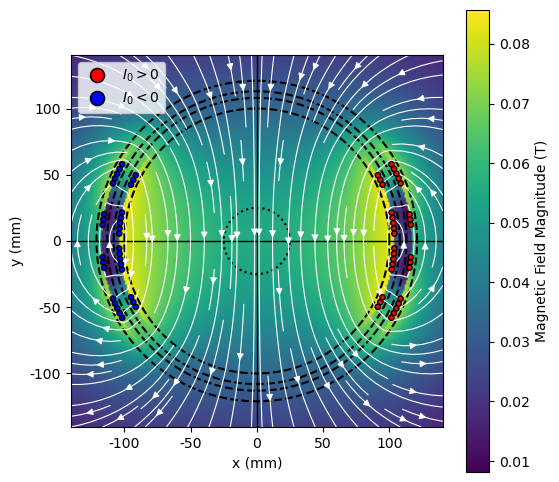

CPU times: total: 14 s
Wall time: 14.1 s


In [10]:
%%time

run_preopt = True

if run_preopt:
    # Pre-optimization modeling: 
    
    pre_opt_model = field_calc()
    
    # Assign values based on this pre_opt model:
    pre_x_vals = pre_opt_model["x_tot"]
    pre_y_vals = pre_opt_model["y_tot"]
    pre_rads = pre_opt_model["rads"]
    pre_Bx_total = pre_opt_model["Bx_total"]
    pre_By_total = pre_opt_model["By_total"]
    pre_B_mag = pre_opt_model["B_mag"]
    pre_X = pre_opt_model["X"]
    pre_Y = pre_opt_model["Y"]
    
    plot_field(pre_x_vals, pre_y_vals, pre_Bx_total, pre_By_total, pre_B_mag, pre_rads, pre_X, pre_Y, "PreOptimizationPlot")
else:
    pass

## Optimization:

In [11]:
# =============== Optimization Functions ===============
def get_spacing_vector():
    """Flatten all user-specified spacings into a 1D vector."""
    vec = []
    for layer in layers:
        vec.extend(layer[1])  # only second element = spacing list
    return np.array(vec, dtype=float)


def set_spacing_vector(vec):
    """Replace all spacing values inside layers using a 1D vector."""
    idx = 0
    for layer in layers:
        count = len(layer[1])
        layer[1] = list(vec[idx:idx+count])
        idx += count

# Calculates the cost, based on the spacing vector and the harmonic weights
def objective(vec):
    # 1. Insert parameters (spacings)
    set_spacing_vector(vec)


    # !!!!!!!!!!!!!! I don't think these initial values from the pre-optimization run are even needed !!!!!!!!!!!!!!
    
    # 2. Recompute full magnet once
    #results = run_full_magnet_calculation()
    #units = pre_optimization["harm_units"]
    # Pre-optimization radii
    #rads = pre_rads 

    # =============== GEOMETRY CONSTRAINT CHECK ===============
    penalty = 0
    scale_overlap = 1e6     # penalty weight for block overlap
    scale_sym     = 1e7     # penalty weight for violating symmetry angle

    # Retrieve needed geometry info
    rel_spacing = [layer[1] for layer in layers]
    cond_nums   = [layer[0] for layer in layers]

    # Recompute delta_thetas (block angular widths, in degrees)
    delta_thetas = []
    for i, rad in enumerate(rads):
        temp = []
        for num in cond_nums[i]:
            temp.append(np.rad2deg((2*num*wire_rad) / rad))
        delta_thetas.append(temp)

    # Recompute block start angles lower_angles (degrees)
    lower_angles = []
    for i, space_list in enumerate(rel_spacing):
        accum = 0
        temp = []
        for j, sp in enumerate(space_list):
            temp.append(accum + sp)
            accum += delta_thetas[i][j] + sp
        lower_angles.append(temp)

    # Apply constraints per layer
    for i in range(len(lower_angles)):

        # 1. Overlap constraint: end(j) < start(j+1)
        for j in range(len(lower_angles[i]) - 1):
            end_j = lower_angles[i][j] + delta_thetas[i][j]
            start_j1 = lower_angles[i][j+1]

            if end_j > start_j1:  # Overlap detected
                penalty += scale_overlap * (end_j - start_j1)**2

        # 2. Symmetry angle constraint
        last_end = lower_angles[i][-1] + delta_thetas[i][-1]
        if last_end > np.rad2deg(sym_angle):
            penalty += scale_sym * (last_end - np.rad2deg(sym_angle))**2


    # =============== HARMONIC OBJECTIVE ===============

    # Recompute geometry + harmonics for THIS spacing vector
    geometry_generation()                         # updates conductor positions
    harm_results = harm_calculation()             # fresh computation
    units = harm_results["harm_units"]            # depends on vec

    cost = 0.0

    for n_label, spec in harmonic_weights.items():
        idx = n_label - 1                         # 1-based -> 0-based
        w = float(spec["weight"])
        u = float(units[idx])

        # Target = 0 (minimize harmonic magnitude)
        cost += w * (u**2)

    total = float(cost + penalty)

    # Safety guards (optional but recommended)
    if not np.isfinite(total):
        return 1e30

    return total

In [12]:
# Random seed makes runs converge consistently
np.random.seed(12345)
# Gets the initial spacing vector in the proper format
initial_vec = get_spacing_vector()

In [13]:
harmonic_weights = {
    1:  {"weight": 1}, # Dipole       
    2:  {"weight": 1}, # Quadrupole
    3:  {"weight": 1}, # Sextupole
    4:  {"weight": 1}, # etc.
    5:  {"weight": 200},
    6:  {"weight": 1},
    7:  {"weight": 1},    
    8:  {"weight": 1},
    9:  {"weight": 1},
    10: {"weight": 1},    
    11: {"weight": 1},
    12: {"weight": 1},
    13: {"weight": 1},    
    14: {"weight": 1},
    15: {"weight": 1},
    16: {"weight": 1},    
    17: {"weight": 1},
    18: {"weight": 1},
    19: {"weight": 1},    
    20: {"weight": 1},
}

In [14]:
%%time
# =============== OPTIMIZATION ALGORITHM ===============

# Random seed makes runs converge consistently
np.random.seed(1234567)
# Gets the initial spacing vector in the proper format
initial_vec = get_spacing_vector()

# Prior parameters
param = ng.p.Array(init=initial_vec).set_bounds(0, np.rad2deg(sym_angle))
optimizer = ng.optimizers.OnePlusOne(
    parametrization=param,
    budget=1000, # Number of objective function evaluations (i.e. samples)
)

# ----- tqdm progress loop -----
for _ in tqdm(range(optimizer.budget), desc="Optimizing spacing"):
    candidate = optimizer.ask()
    value = objective(candidate.value)   # evaluate your function
    optimizer.tell(candidate, value)

recommendation = optimizer.provide_recommendation()
best_vec = recommendation.value
# set_spacing_vector directly changes the layer condition for the next run of the script
set_spacing_vector(best_vec)
# --------------------------------
print("Best spacings found:", best_vec)

# Layers has now been changed, so geometry needs to be ran again, then we can re-run the model, and the plot the new harmonics (basically re-run everything)
# THIS LINE SETS THE NEW GEOMETRY WITH THE OPTIMIZED SPACING!!!
geometry_generation()

post_optimization = harm_calculation()
print(f"Post-Optimzation Harmonics: {post_optimization['harm_units']}")

Optimizing spacing: 100%|██████████| 1000/1000 [00:06<00:00, 154.94it/s]

Best spacings found: [38.1871529159 28.5516645823 2.6587367516 4.3815609939]
Post-Optimzation Harmonics: [10000.0000000000 -0.0000000000 -0.0000025242 -0.0000000000 -0.0000061020
 0.0000000000 -0.0124046986 0.0000000000 0.0527903203 -0.0000000000
 -0.0031464610 -0.0000000000 -0.0000417475 -0.0000000000 -0.0000007376
 0.0000000000 0.0000004556 -0.0000000000 -0.0000000068 -0.0000000000]
CPU times: total: 6.47 s
Wall time: 6.47 s


In [15]:
%%time

# Now we calculate the total field for this new optimized model:
post_opt_model = field_calc()

# Assign values based on this post_opt model:
post_x_vals = post_opt_model["x_tot"]
post_y_vals = post_opt_model["y_tot"]
post_rads = post_opt_model["rads"]
post_Bx_total = post_opt_model["Bx_total"]
post_By_total = post_opt_model["By_total"]
post_B_mag = post_opt_model["B_mag"]
post_X = post_opt_model["X"]
post_Y = post_opt_model["Y"]

CPU times: total: 7.7 s
Wall time: 7.77 s


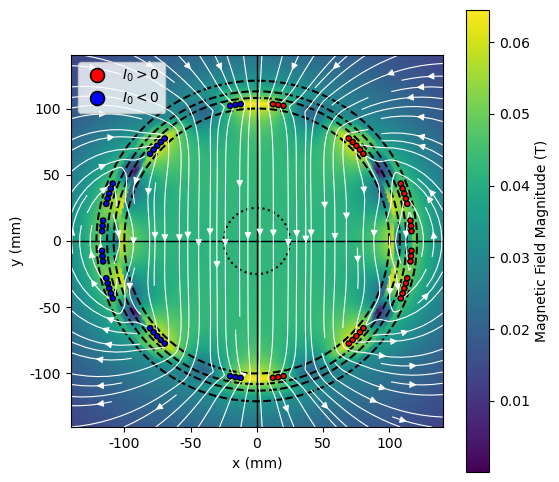

In [16]:
plot_field(post_x_vals, post_y_vals, post_Bx_total, post_By_total, post_B_mag, post_rads, post_X, post_Y, "PostOptimizationPlot")